# MovieLens 100K Data Loading & Exploration

This notebook loads and explores the MovieLens 100K dataset.

In [5]:
import sys
sys.path.append('../src')

from data_loader import MovieLensDataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Download MovieLens 100K Dataset

In [6]:

# Initialize data loader — paths are resolved automatically from src/data_loader.py
loader = MovieLensDataLoader()

# Download dataset (skips if already present)
loader.download_dataset()


📥 Downloading MovieLens 100K dataset from http://files.grouplens.org/datasets/movielens/ml-100k.zip...
✅ Download complete! (4.7 MB)
📂 Extracting to data/raw/...
✅ Extraction complete!
✅ Verified: u.data exists at data/raw/ml-100k\u.data
📋 Files in ml-100k folder: ['allbut.pl', 'mku.sh', 'README', 'u.data', 'u.genre', 'u.info', 'u.item', 'u.occupation', 'u.user', 'u1.base', 'u1.test', 'u2.base', 'u2.test', 'u3.base', 'u3.test', 'u4.base', 'u4.test', 'u5.base', 'u5.test', 'ua.base', 'ua.test', 'ub.base', 'ub.test']


In [7]:

# Verify dataset location
import os
raw_dir = os.path.join(os.path.dirname(os.path.dirname(os.path.abspath('.'))), 
                        'Ecommerce_recommendation', 'data', 'raw')
# Simpler: just check relative to notebook location
data_path = os.path.normpath(os.path.join('..', 'data', 'raw', 'ml-100k'))
print(f"📁 Data path: {os.path.abspath(data_path)}")
if os.path.exists(data_path):
    files = os.listdir(data_path)
    print(f"✅ Found {len(files)} files: {files[:5]} ...")
else:
    print(f"❌ Not found — run the download cell above first.")


📁 Data path: s:\projects\Temp\Ecommerce_recommendation\data\raw\ml-100k
✅ Found 23 files: ['allbut.pl', 'mku.sh', 'README', 'u.data', 'u.genre'] ...


## 2. Load Data

In [8]:
# Load data
ratings, movies, users = loader.load_data()

print('Ratings shape:', ratings.shape)
print('Movies shape:', movies.shape)
print('Users shape:', users.shape)

# Display first few rows
print("\nFirst 5 ratings:")
print(ratings.head())

Ratings shape: (100000, 4)
Movies shape: (1682, 24)
Users shape: (943, 5)

First 5 ratings:
   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596


## 3. Dataset Statistics

In [9]:
# Print statistics
loader.get_statistics()

MovieLens 100K Dataset Statistics
Total Ratings: 100,000
Unique Users: 943
Unique Movies: 1,682
Rating Range: 1 - 5
Sparsity:  0.9370


## 4. Rating Distribution

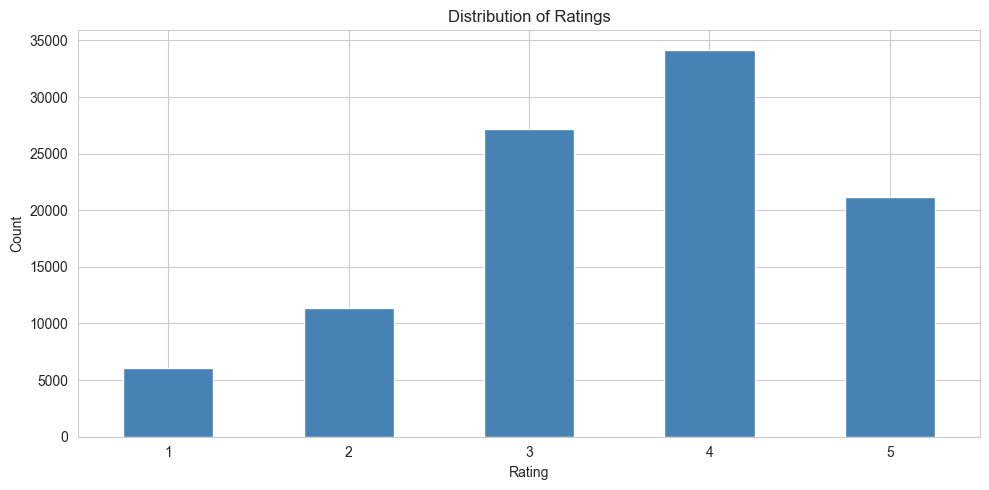

Rating statistics:
count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


In [10]:
# Rating distribution
plt.figure(figsize=(10, 5))
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Rating statistics:")
print(ratings['rating'].describe())

## 5. User & Movie Statistics

User Rating Count Statistics:
count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
Name: rating, dtype: float64

Item Rating Count Statistics:
count    1682.000000
mean       59.453032
std        80.383846
min         1.000000
25%         6.000000
50%        27.000000
75%        80.000000
max       583.000000
Name: rating, dtype: float64


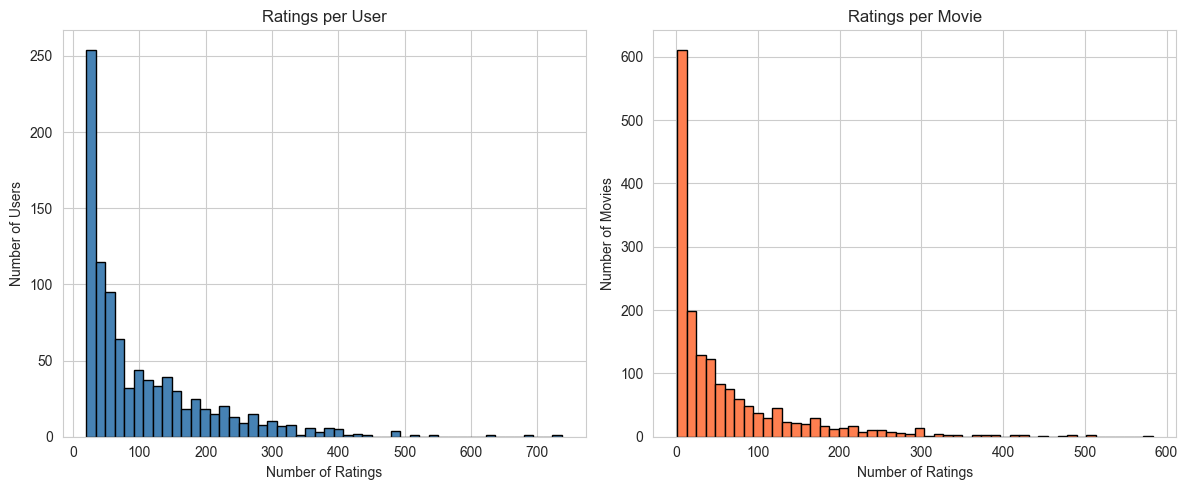

In [11]:
# Ratings per user
user_ratings = ratings.groupby('user_id')['rating'].count()

print("User Rating Count Statistics:")
print(user_ratings.describe())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(user_ratings, bins=50, color='steelblue', edgecolor='black')
plt.title('Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')

# Ratings per item
item_ratings = ratings.groupby('item_id')['rating'].count()
print("\nItem Rating Count Statistics:")
print(item_ratings.describe())

plt.subplot(1, 2, 2)
plt.hist(item_ratings, bins=50, color='coral', edgecolor='black')
plt.title('Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

## 6. Create User-Item Matrix

User-Item Matrix shape: (943, 1682)
Matrix sparsity: 0.9370


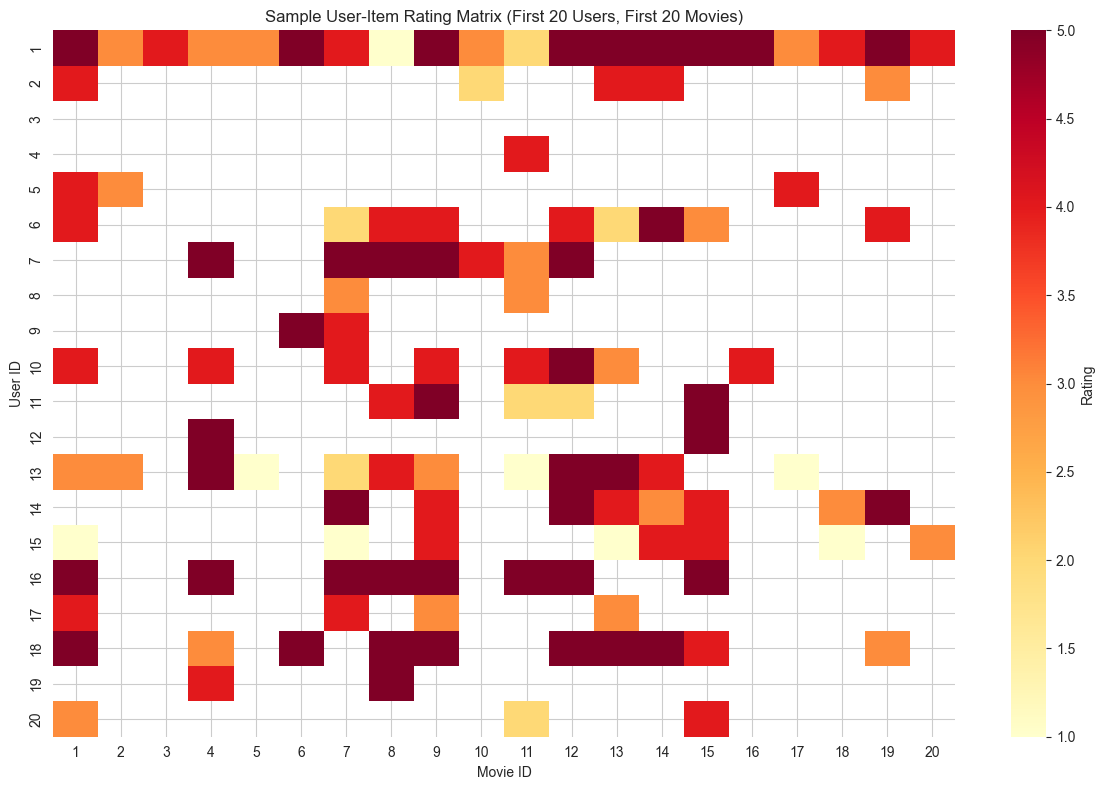

In [12]:
# Create user-item matrix
user_item_matrix = loader.get_user_item_matrix()

print(f"User-Item Matrix shape: {user_item_matrix.shape}")
print(f"Matrix sparsity: {user_item_matrix.isna().sum().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1]):.4f}")

# Visualize small portion of matrix
plt.figure(figsize=(12, 8))
sns.heatmap(user_item_matrix.iloc[:20, :20], cmap='YlOrRd', cbar_kws={'label': 'Rating'})
plt.title('Sample User-Item Rating Matrix (First 20 Users, First 20 Movies)')
plt.xlabel('Movie ID')
plt.ylabel('User ID')
plt.tight_layout()
plt.show()

## 7. Save Processed Data

In [13]:
# Save processed data
ratings.to_csv('../data/processed/ratings.csv', index=False)
movies.to_csv('../data/processed/movies.csv', index=False)
users.to_csv('../data/processed/users.csv', index=False)
user_item_matrix.to_csv('../data/processed/user_item_matrix.csv')

print("Data saved successfully!")

Data saved successfully!
